In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [4]:
sentiment_df = pd.read_csv(r"C:\Users\anjal\OneDrive\Documents\fear_greed_index.csv")
trades_df = pd.read_csv(r"C:\Users\anjal\OneDrive\Documents\historical_data.csv")


In [5]:
sentiment_df.head(4)
trades_df.head(4)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12


In [6]:
#basic data understanding
print("sentiment shape:",sentiment_df.shape)
print("trades shape:",trades_df.shape)

sentiment shape: (2644, 4)
trades shape: (211224, 16)


In [7]:
#missing values
sentiment_df.isna().sum()
trades_df.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
#duplicate rows
sentiment_df.duplicated().sum()
trades_df.duplicated().sum()

np.int64(0)

In [33]:
#date and time handling in sentiment dataset
sentiment_df['timestamp']=pd.to_datetime(sentiment_df['timestamp'], unit='s')
sentiment_df['date']=pd.to_datetime(sentiment_df['date'], dayfirst=True)

trades_df['timestamp']=pd.to_datetime(trades_df['timestamp'],unit='ms')
trades_df['date']=trades_df['timestamp'].dt.date

In [13]:
sentiment_df.columns=sentiment_df.columns.str.lower()
sentiment_df.columns=sentiment_df.columns.str.replace(' ','_')
trades_df.columns=trades_df.columns.str.lower()
trades_df.columns=trades_df.columns.str.replace(' ','_')

In [15]:
trades_df.head(4)

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27


In [16]:
trades_df['is_long']=trades_df['side'].str.lower().eq('buy').astype(int)

In [36]:
#daily metrics per account
daily_metrics=trades_df.groupby(['date','account']).agg(
    daily_pnl=('closed_pnl','sum'),
    trade_count=('closed_pnl','count'),
    avg_trade_size=('size_usd','mean'),
    long_ratio=('is_long','mean')).reset_index()
daily_metrics['date']=pd.to_datetime(daily_metrics['date'])

In [37]:
daily_metrics.head()

,date,account,daily_pnl,trade_count,avg_trade_size,long_ratio
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,1.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,2,23066.935000,1.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,1043,11034.799511,0.468840
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,27,3048.594444,0.148148
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,88,1136.312727,1.000000


In [40]:
#win rate
trades_df['win']=(trades_df['closed_pnl']>0).astype(int)
win_rate=trades_df.groupby(['date','account'])['win'].mean().reset_index(name='win_rate')
win_rate['date']=pd.to_datetime(win_rate['date'])

daily_metrics=daily_metrics.merge(win_rate, on=['date','account'], how= 'left')

In [42]:
#merge with sntiment data
final_df=daily_metrics.merge(sentiment_df[['date','classification']] , how='inner',on='date')

In [43]:
final_df.head(5)

,date,account,daily_pnl,trade_count,avg_trade_size,long_ratio,win_rate,classification
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,1.000000,0.000000,Greed
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,2,23066.935000,1.000000,0.000000,Greed
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,1043,11034.799511,0.468840,0.275168,Greed
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,27,3048.594444,0.148148,0.333333,Extreme Greed
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,88,1136.312727,1.000000,0.000000,Extreme Greed


In [ ]:
#part B
#Analysis
#we will break this into 3 sections, matching the question

In [46]:
# B1--Does performence differ between fear vs greed days?
performance_sentiment=(final_df.groupby('classification').
    agg(
        avg_daily_pnl=('daily_pnl','mean'),
        median_daily_pnl=('daily_pnl','median'),
        avg_win_rate=('win_rate','mean'),
        loss_day_ratio=('daily_pnl',lambda x:(x<0).mean())).reset_index()
                      )
                       

In [47]:
performance_sentiment.head(4)

,classification,avg_daily_pnl,median_daily_pnl,avg_win_rate,loss_day_ratio
0,Extreme Greed,35393.098355,0.000000,0.336609,0.40000
1,Fear,209372.662205,81389.682515,0.415878,0.06250
2,Greed,99675.516731,35988.376437,0.374074,0.03125
3,Neutral,19842.797260,-0.418640,0.260683,0.50000


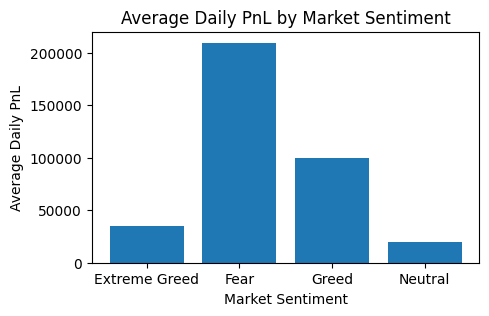

In [50]:
# average daily pnl by sentiment
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.bar(
    performance_sentiment['classification'],performance_sentiment['avg_daily_pnl'])
plt.title('Average Daily PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL')
plt.show()
    

In [ ]:
# Insight-- Average Daily PnL by Market Sentiment
# Fear sentiment days show the **Highest average daily PnL** , suggesting that trader benefit from higher volatility
#and short-term price dislocations during market stress. Greed and Ex. greed days deliver comparatively lower returns, while nuteral
#periods exhibit the weakest performance due to limited market movement.

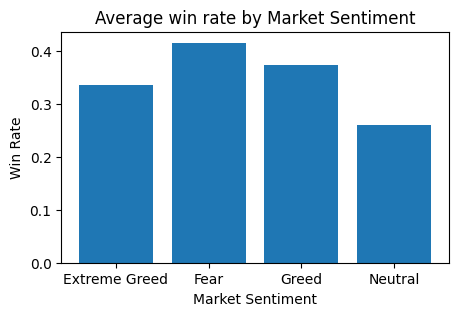

In [51]:
plt.figure(figsize=(5,3))
plt.bar(
    performance_sentiment['classification'],performance_sentiment['avg_win_rate'])
plt.title('Average win rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.show()
    

In [ ]:
#Average win rate by Market Sentiment
#Fear sentiment shows the **Highest win rate(~0.40)**, followed by greed and ex> greed. 
# neutral sentiment has the lowest win rate(below ~0.30), indicating weaker trading opportunities in low-momentum market.

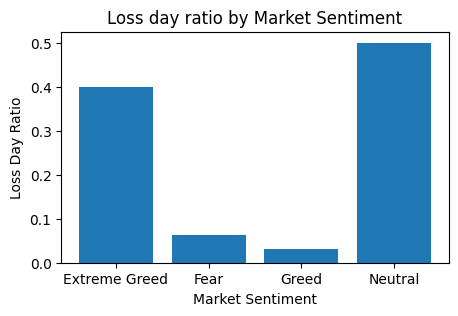

In [52]:
plt.figure(figsize=(5,3))
plt.bar(
    performance_sentiment['classification'],performance_sentiment['loss_day_ratio'])
plt.title('Loss day ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Loss Day Ratio')
plt.show()
    

In [ ]:
#Insight-- Loss day ratio by Market Sentiment
# neutral sentiment records the **highest loss-day ratio(~0.5), indicating a greater frequency of unprofitable days in low momentum markets.
#loss day ratio decline during ex. greed and fear periods, with greed showing the lowest loss frequency, suggesting relatively more consistent 
#prformance during optimstic market conditions

In [53]:
#B2-- Traded Behaviour analysis
behavior_sentiment=(final_df.groupby('classification').agg
                    (avg_trade_count=('trade_count','mean'),
                     avg_trade_size=('avg_trade_size','mean'),
                     avg_long_ratio=('long_ratio','mean')).reset_index()
                   )

In [54]:
behavior_sentiment.head(4)

,classification,avg_trade_count,avg_trade_size,avg_long_ratio
0,Extreme Greed,1392.40000,4344.447836,0.518479
1,Fear,4183.46875,5926.522723,0.459352
2,Greed,1134.03125,5839.310974,0.495780
3,Neutral,892.62500,3793.444161,0.468967


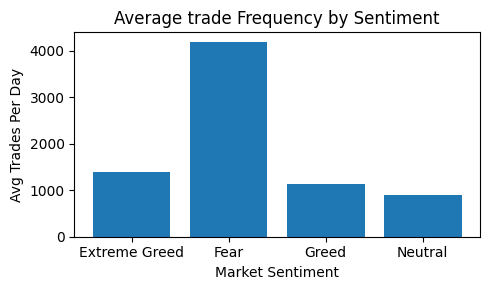

In [57]:
#Trade frequency vs Sentiment
plt.figure(figsize=(5,3))
plt.bar(
    behavior_sentiment['classification'],behavior_sentiment['avg_trade_count'])
plt.title('Average trade Frequency by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Avg Trades Per Day')
plt.tight_layout()
plt.show()
    

In [ ]:
# Insight-- Average trade Frequency by Sentiment
#Trader execute the ** most trades per day durnig the fear sentiment** followed by Ex. greed, greed and neutral.
#this suggest that market stress encourages higher trading activity, while calmer and bullish market see comparatively fewer trades.

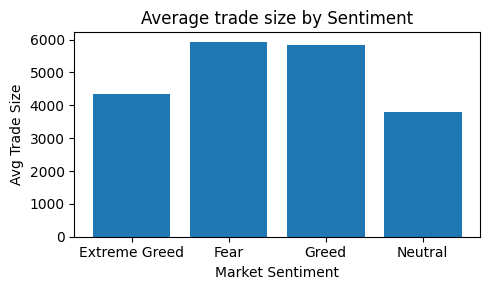

In [72]:
#position size vs Sentiment
plt.figure(figsize=(5,3))
plt.bar(
    behavior_sentiment['classification'],behavior_sentiment['avg_trade_size'])
plt.title('Average trade size by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Avg Trade Size')
plt.tight_layout()
plt.show()
    

In [ ]:
# Insight-- Average trade size by Sentiment
# Average trade size are similar for fear and greed(~6000), indicating comparable risk exposure in these regimes.
#Ex. greed slightly exceeds Neutral, suggesting that traders take moderate positions during highly optimistic market,
# while the smallest position occur in neutral sentiment

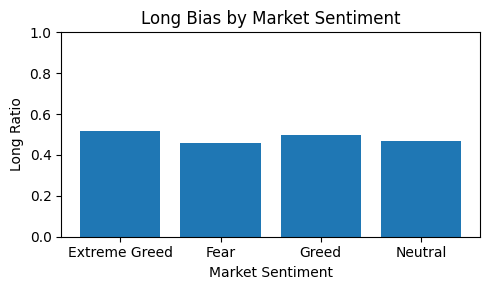

In [59]:
#long/short bias vs Sentiment
plt.figure(figsize=(5,3))
plt.bar(
    behavior_sentiment['classification'],behavior_sentiment['avg_long_ratio'])
plt.title('Long Bias by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long Ratio')
plt.ylim(0,1)
plt.tight_layout()
plt.show()
    


In [ ]:
#Insight-- Long Bias by Market Sentiment
#All sentiment regimes have a ** Long ratio between 0.4 and 0.6**, indicating a relatively balanced long/short bias

In [61]:
#segment 1-- High vs low Leverage Traders
final_df['leverage_segment']=pd.qcut(final_df['avg_trade_size'], q=2, labels=['Low Risk','High Risk'])

In [62]:
#Analyze performance by sentiment
leverage_segment_analysis = (
    final_df
    .groupby(['leverage_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        avg_win_rate=('win_rate', 'mean')
    )
    .reset_index()
)


C:\Users\anjal\AppData\Local\Temp\ipykernel_9180\865328813.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['leverage_segment', 'classification'])


In [63]:
leverage_segment_analysis.head(3)

,leverage_segment,classification,avg_pnl,avg_win_rate
0,Low Risk,Extreme Greed,0.000000,0.000000
1,Low Risk,Fear,112831.554518,0.429923
2,Low Risk,Greed,143718.073412,0.366315


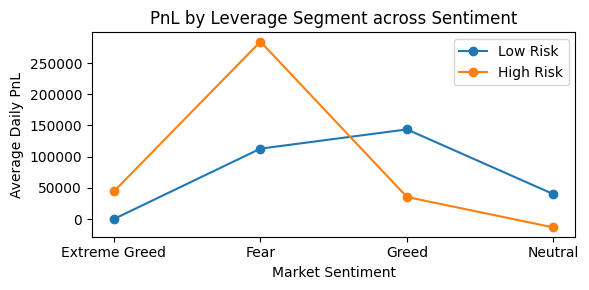

In [64]:
#pnl by leverage segment
plt.figure(figsize=(6,3))
for seg in leverage_segment_analysis['leverage_segment'].unique():
    subset = leverage_segment_analysis[
        leverage_segment_analysis['leverage_segment'] == seg
    ]
    plt.plot(subset['classification'], subset['avg_pnl'], marker='o', label=seg)

plt.title("PnL by Leverage Segment across Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Insight--PnL by Leverage Segment across Sentiment
# High-risk traders achieve the **highest average daily PnL during Fear sentiment**, followed by Greed,
# while Low-risk traders perform best in moderate regimes. High-risk performance
# drops in Neutral, and Low-risk traders see lower PnL in Extreme Greed, indicating that
# leverage amplifies both gains and losses depending on market sentiment.

In [65]:
#SEGMENT 2: Frequent vs Infrequent Traders
final_df['frequency_segment'] = pd.qcut(
    final_df['trade_count'],
    q=2,
    labels=['Infrequent', 'Frequent']
)


In [66]:
#Analyze
frequency_analysis = (
    final_df
    .groupby(['frequency_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        avg_trade_count=('trade_count', 'mean')
    )
    .reset_index()
)

frequency_analysis


C:\Users\anjal\AppData\Local\Temp\ipykernel_9180\1834544294.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['frequency_segment', 'classification'])


,frequency_segment,classification,avg_pnl,avg_trade_count
0,Infrequent,Extreme Greed,-4494.495724,281.666667
1,Infrequent,Fear,42168.941645,349.125000
2,Infrequent,Greed,28452.671557,225.130435
3,Infrequent,Neutral,26254.572028,75.800000
4,Frequent,Extreme Greed,95224.489473,3058.500000
5,Frequent,Fear,265107.235726,5461.583333
6,Frequent,Greed,281689.454396,3456.777778
7,Frequent,Neutral,9156.505979,2254.000000


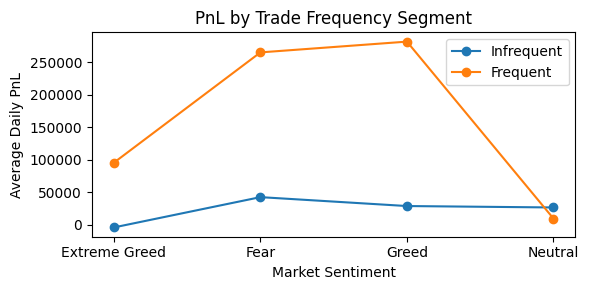

In [67]:
plt.figure(figsize=(6,3))
for seg in frequency_analysis['frequency_segment'].unique():
    subset = frequency_analysis[
        frequency_analysis['frequency_segment'] == seg
    ]
    plt.plot(subset['classification'], subset['avg_pnl'], marker='o', label=seg)

plt.title("PnL by Trade Frequency Segment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Insight — PnL by Trade Frequency Segment

# Frequent traders achieve the **highest average daily PnL during Greed**, slightly below Fear,
# while Neutral and Extreme Greed yield minimal or zero PnL. Infrequent traders show lower and
# more stable PnL across all sentiments, indicating that frequent trading is more profitable
# in favorable market conditions but offers limited gains during extreme or neutral regimes.


In [69]:
final_df['consistency_segment'] = final_df['win_rate'].apply(
    lambda x: 'Consistent' if x >= 0.5 else 'Inconsistent'
)


In [70]:
consistency_analysis = (
    final_df
    .groupby(['consistency_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean')
    )
    .reset_index()
)

consistency_analysis


,consistency_segment,classification,avg_pnl
0,Consistent,Extreme Greed,187842.084190
1,Consistent,Fear,79488.917488
2,Consistent,Greed,261749.338310
3,Consistent,Neutral,145563.448374
4,Inconsistent,Extreme Greed,-2719.148104
5,Inconsistent,Fear,227927.482879
6,Inconsistent,Greed,14779.705427
7,Inconsistent,Neutral,1882.704243


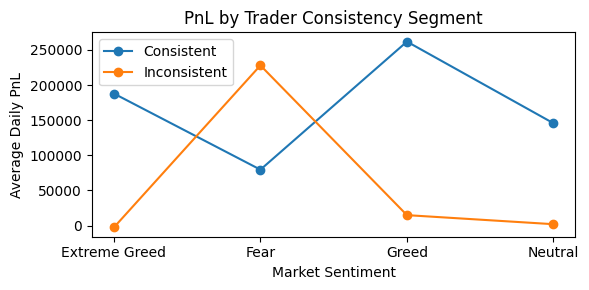

In [71]:
plt.figure(figsize=(6,3))
for seg in consistency_analysis['consistency_segment'].unique():
    subset = consistency_analysis[
        consistency_analysis['consistency_segment'] == seg
    ]
    plt.plot(subset['classification'], subset['avg_pnl'], marker='o', label=seg)

plt.title("PnL by Trader Consistency Segment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Insight — PnL by Trader Consistency Segment

# Consistent traders achieve the **highest average daily PnL during Greed** and the lowest during Fear,
# with similar performance in Extreme Greed and Neutral. Inconsistent traders perform best in
# Fear, minimal in Extreme Greed, and modestly above zero in Greed and Neutral. This suggests
# that consistency provides stable gains in optimistic markets, while inconsistent traders
# experience high variability depending on sentiment.


In [ ]:
# Part C — Actionable Strategy Recommendations

# Strategy 1: Sentiment-Aware Leverage Control
**Observation:**  
High-risk traders achieve the highest PnL during Fear, but performance drops in Neutral and Extreme Greed.
    Loss-day ratios are also higher in Neutral and Fear, indicating increased risk.

**Rule of Thumb:**  
Reduce leverage and position size for high-risk traders during Fear and Neutral periods. Allow higher leverage only during Greed regimes.

**Rationale:**  
Limits losses during volatile markets while allowing upside when sentiment favors risk-taking.


# Strategy 2: Trade Frequency Adjustment
**Observation:**  
Frequent traders perform best in Greed periods, while Fear and Neutral yield minimal or zero PnL. Infrequent traders show lower,
more stable returns across sentiments.

**Rule of Thumb:**  
Enable higher trade frequency only for frequent, consistent traders during Greed periods. Restrict trade frequency during Fear and Extreme Greed.

**Rationale:**  
Rewards proven traders in favorable markets and avoids noise-driven losses in high-uncertainty periods.


# Strategy 3: Consistency-Based Risk Management (Optional)
**Observation:**  
Consistent traders maintain stable PnL across most sentiments, while inconsistent traders have high variability, especially in Fear.

**Rule of Thumb:**  
Apply stricter risk limits or cooldown periods for inconsistent traders during Fear periods.

**Rationale:**  
Protects traders from large drawdowns and encourages disciplined trading.

